In [167]:
#!pip install xarray
#!pip install scipy
#!pip install cdsapi

#### Import Libraries

In [168]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt
import math

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

#### Define Slice Function

The coordinates have to be defined in 0-360 format.

In [169]:
def spatial_subset(ds):
    out = ds.sel(lon = slice(350.0, 355.0),
                 lat = slice(36.0, 42.3))
    return out

## Get Baseline

The baselilne used is 1991-2021

In [170]:
baseline_df = pd.DataFrame()
for year in range(1981, 2022):

    var = xr.open_dataset(f"oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    print(f'Opening {year}')
    
    var_sel = spatial_subset(var)
    
    var_sst = var_sel["sst"]

    baseline_df = pd.concat([baseline_df, var_sst.to_dataframe()])
    
del var

Opening 1981
Opening 1982
Opening 1983


FileNotFoundError: [Errno 2] No such file or directory: '/Users/miguelsilveira/Documents/GitHub/marineheatwaves/oisst_daily/sst.day.mean.1984.nc'

## Years to be Analysed

In [ ]:

y2010 = xr.open_dataset("oisst_daily/sst.day.mean.2010.nc", 
                        engine="netcdf4", decode_times=True)
y2011 = xr.open_dataset("oisst_daily/sst.day.mean.2011.nc", 
                        engine="netcdf4", decode_times=True)
y2012 = xr.open_dataset("oisst_daily/sst.day.mean.2012.nc", 
                        engine="netcdf4", decode_times=True)
y2013 = xr.open_dataset("oisst_daily/sst.day.mean.2013.nc", 
                        engine="netcdf4", decode_times=True)
y2014 = xr.open_dataset("oisst_daily/sst.day.mean.2014.nc", 
                        engine="netcdf4", decode_times=True)

y2015 = xr.open_dataset("oisst_daily/sst.day.mean.2015.nc", 
                        engine="netcdf4", decode_times=True)
y2016 = xr.open_dataset("oisst_daily/sst.day.mean.2016.nc", 
                        engine="netcdf4", decode_times=True)
y2017 = xr.open_dataset("oisst_daily/sst.day.mean.2017.nc", 
                        engine="netcdf4", decode_times=True)
y2018 = xr.open_dataset("oisst_daily/sst.day.mean.2018.nc", 
                        engine="netcdf4", decode_times=True)
y2019 = xr.open_dataset("oisst_daily/sst.day.mean.2019.nc", 
                        engine="netcdf4", decode_times=True)

y2020 = xr.open_dataset("oisst_daily/sst.day.mean.2020.nc", 
                        engine="netcdf4", decode_times=True)
y2021 = xr.open_dataset("oisst_daily/sst.day.mean.2021.nc", 
                        engine="netcdf4", decode_times=True)
y2022 = xr.open_dataset("oisst_daily/sst.day.mean.2022.nc", 
                        engine="netcdf4", decode_times=True)
y2023 = xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", 
                        engine="netcdf4", decode_times=True)
y2024 = xr.open_dataset("oisst_daily/sst.day.mean.2024.nc", 
                        engine="netcdf4", decode_times=True)
y2025 = xr.open_dataset("oisst_daily/sst.day.mean.2025.nc", 
                        engine="netcdf4", decode_times=True)

#### Slice datasets' coordinates

In [ ]:
y2010_sel = spatial_subset(y2010)
y2010_sst = y2010_sel["sst"]
y2010_time = y2010_sel["time"]

y2011_sel = spatial_subset(y2011)
y2011_sst = y2011_sel["sst"]
y2011_time = y2011_sel["time"]

y2012_sel = spatial_subset(y2012)
y2012_sst = y2012_sel["sst"]
y2012_time = y2012_sel["time"]

y2013_sel = spatial_subset(y2013)
y2013_sst = y2013_sel["sst"]
y2013_time = y2013_sel["time"]

y2014_sel = spatial_subset(y2014)
y2014_sst = y2014_sel["sst"]
y2014_time = y2014_sel["time"]

y2015_sel = spatial_subset(y2015)
y2015_sst = y2015_sel["sst"]
y2015_time = y2015_sel["time"]

y2016_sel = spatial_subset(y2016)
y2016_sst = y2016_sel["sst"]
y2016_time = y2016_sel["time"]

y2017_sel = spatial_subset(y2017)
y2017_sst = y2017_sel["sst"]
y2017_time = y2017_sel["time"]

y2018_sel = spatial_subset(y2018)
y2018_sst = y2018_sel["sst"]
y2018_time = y2018_sel["time"]

y2019_sel = spatial_subset(y2019)
y2019_sst = y2019_sel["sst"]
y2019_time = y2019_sel["time"]

y2020_sel = spatial_subset(y2020)
y2020_sst = y2020_sel["sst"]
y2020_time = y2020_sel["time"]

y2021_sel = spatial_subset(y2021)
y2021_sst = y2021_sel["sst"]
y2021_time = y2021_sel["time"]

y2022_sel = spatial_subset(y2022)
y2022_sst = y2022_sel["sst"]
y2022_time = y2022_sel["time"]

y2023_sel = spatial_subset(y2023)
y2023_sst = y2023_sel["sst"]
y2023_time = y2023_sel["time"]

y2024_sel = spatial_subset(y2024)
y2024_sst = y2024_sel["sst"]
y2024_time = y2024_sel["time"]

y2025_sel = spatial_subset(y2025)
y2025_sst = y2025_sel["sst"]
y2025_time = y2025_sel["time"]

In [ ]:
baseline_df = baseline_df.reset_index()

y2010_df = y2010_sst.to_dataframe().reset_index()
y2011_df = y2011_sst.to_dataframe().reset_index()
y2012_df = y2012_sst.to_dataframe().reset_index()
y2013_df = y2013_sst.to_dataframe().reset_index()
y2014_df = y2014_sst.to_dataframe().reset_index()
y2015_df = y2015_sst.to_dataframe().reset_index()
y2016_df = y2016_sst.to_dataframe().reset_index()
y2017_df = y2017_sst.to_dataframe().reset_index()
y2018_df = y2018_sst.to_dataframe().reset_index()
y2019_df = y2019_sst.to_dataframe().reset_index()
y2020_df = y2020_sst.to_dataframe().reset_index()
y2021_df = y2021_sst.to_dataframe().reset_index()
y2022_df = y2022_sst.to_dataframe().reset_index()
y2023_df = y2023_sst.to_dataframe().reset_index()
y2024_df = y2024_sst.to_dataframe().reset_index()
y2025_df = y2025_sst.to_dataframe().reset_index()

## Conversion to ordinal time

In [ ]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

## Detect MHWs

In [ ]:
def detect_mhw_year(year_df, baseline_df, climatology_period=(1991, 2021)):
    
    results = []

    for (lat, lon), group_year in year_df.groupby(["lat", "lon"]):

        # --- year data ---
        y_sst = group_year["sst"].values
        y_time = group_year["time"].values
        y_time_ord = to_ordinal(y_time)

        # --- baseline for same grid cell ---
        base_group = baseline_df[
            (baseline_df["lat"] == lat) &
            (baseline_df["lon"] == lon)
        ]

        if base_group.empty:
            continue

        base_sst = base_group["sst"].values
        base_time = base_group["time"].values
        base_time_ord = to_ordinal(base_time)

        base_years = pd.to_datetime(base_time).year

        if (base_years.min() > climatology_period[0] or
            base_years.max() < climatology_period[1]):
            continue

        # --- MHW detection ---
        mhw_ev, clim = mhw.detect(
            y_time_ord,
            y_sst,
            climatologyPeriod= list(climatology_period),
            alternateClimatology= [base_time_ord, base_sst]
        )

        results.append({
            "year": pd.to_datetime(y_time[0]).year,
            "lat": lat,
            "lon": lon,
            "n_events": mhw_ev["n_events"],
            "total_duration": (
                np.sum(mhw_ev["duration"])
            ),
            "max_intensity": (
                np.max(mhw_ev["intensity_max"])
                if mhw_ev["n_events"] > 0 else np.nan
            ),
            "mean_intensity":
                np.mean(mhw_ev["intensity_max"])

        })

    return pd.DataFrame(results)


In [ ]:
df_2010 = detect_mhw_year(y2010_df, baseline_df)
df_2011 = detect_mhw_year(y2011_df, baseline_df)
df_2012 = detect_mhw_year(y2012_df, baseline_df)
df_2013 = detect_mhw_year(y2013_df, baseline_df)
df_2014 = detect_mhw_year(y2014_df, baseline_df)
df_2015 = detect_mhw_year(y2015_df, baseline_df)
df_2016 = detect_mhw_year(y2016_df, baseline_df)
df_2017 = detect_mhw_year(y2017_df, baseline_df)
df_2018 = detect_mhw_year(y2018_df, baseline_df)
df_2019 = detect_mhw_year(y2019_df, baseline_df)
df_2020 = detect_mhw_year(y2020_df, baseline_df)
df_2021 = detect_mhw_year(y2021_df, baseline_df)
df_2022 = detect_mhw_year(y2022_df, baseline_df)
df_2023 = detect_mhw_year(y2023_df, baseline_df)
df_2024 = detect_mhw_year(y2024_df, baseline_df)
df_2025 = detect_mhw_year(y2025_df, baseline_df)

yearly_dfs = {
    2010: df_2010,
    2011: df_2011,
    2012: df_2012,
    2013: df_2013,
    2014: df_2014,
    2015: df_2015,
    2016: df_2016,
    2017: df_2017,
    2018: df_2018,
    2019: df_2019,
    2020: df_2020,
    2021: df_2021,
    2022: df_2022,
    2023: df_2023,
    2024: df_2024,
    2025: df_2025
}

/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountere

## Graphs

#### By number of events

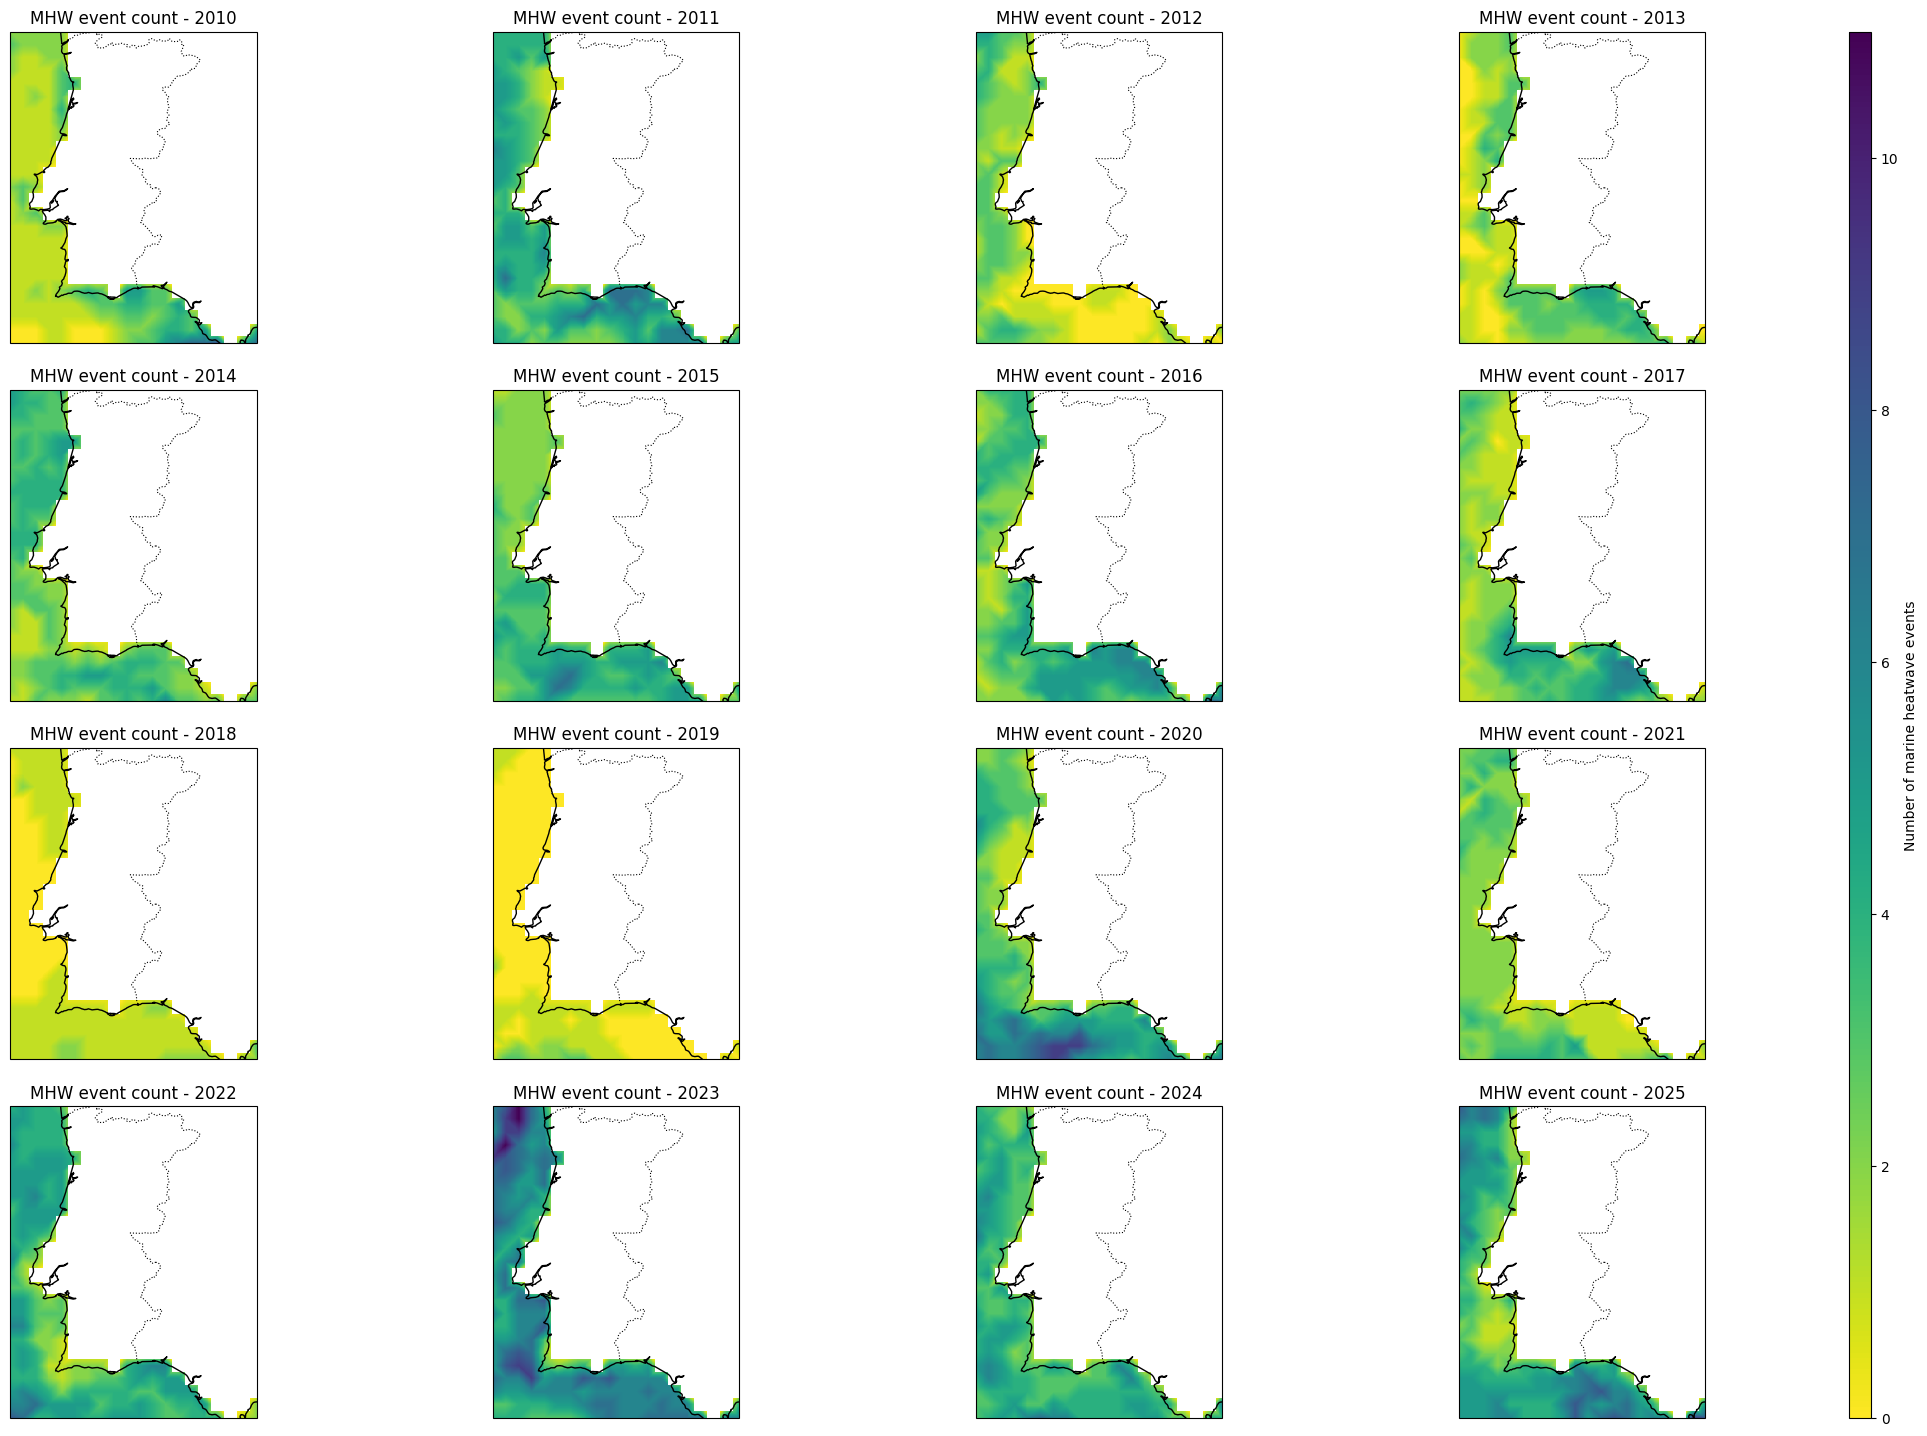

In [ ]:
ds_mask = y2022_sel

# =================================================
# TRUE ocean mask (True = ocean, False = land)
# =================================================
ocean_mask = ~np.isnan(ds_mask["sst"].isel(time=0))

lon_mask = ds_mask["lon"].values
lat_mask = ds_mask["lat"].values
lon2d_mask, lat2d_mask = np.meshgrid(lon_mask, lat_mask)

# =================================================
# Shared interpolation grid (based on all data)
# =================================================
all_lons = np.concatenate([df["lon"].values for df in yearly_dfs.values()])
all_lats = np.concatenate([df["lat"].values for df in yearly_dfs.values()])

lon_grid = np.linspace(all_lons.min(), all_lons.max(), 300)
lat_grid = np.linspace(all_lats.min(), all_lats.max(), 300)
lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

# =================================================
# Interpolate land–sea mask ONCE
# =================================================
mask_interp = griddata(
    (lon2d_mask.ravel(), lat2d_mask.ravel()),
    ocean_mask.values.ravel().astype(float),
    (lon_grid, lat_grid),
    method="nearest"
)

# =================================================
# Figure layout (SCALABLE)
# =================================================
n_panels = len(yearly_dfs)
ncols = 4
nrows = math.ceil(n_panels / ncols)

fig = plt.figure(figsize=(6 * ncols + 1.2, 4.5 * nrows))

gs = GridSpec(
    nrows,
    ncols + 1,
    width_ratios=[1] * ncols + [0.05],
    wspace=0.15,
    hspace=0.15
)

axes = []
for i in range(n_panels):
    r = i // ncols
    c = i % ncols
    ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
    axes.append(ax)

cax = fig.add_subplot(gs[:, -1])

# =================================================
# Shared color scale
# =================================================
vmin = 0
vmax = max(df["n_events"].max() for df in yearly_dfs.values())

# =================================================
# Plot each year
# =================================================
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lons = df["lon"].values
    lats = df["lat"].values
    counts = df["n_events"].values

    # Linear interpolation
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # Nearest fallback (fills coastal gaps)
    grid_counts_nearest = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="nearest"
    )

    grid_counts = np.where(
        np.isnan(grid_counts),
        grid_counts_nearest,
        grid_counts
    )

    # Apply land mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # Map styling
    ax.set_extent(
        [all_lons.min(), all_lons.max(), all_lats.min(), all_lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="viridis_r",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW event count - {year}")

# =================================================
# Shared colorbar
# =================================================
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Number of marine heatwave events")

plt.show()

#### By total duration

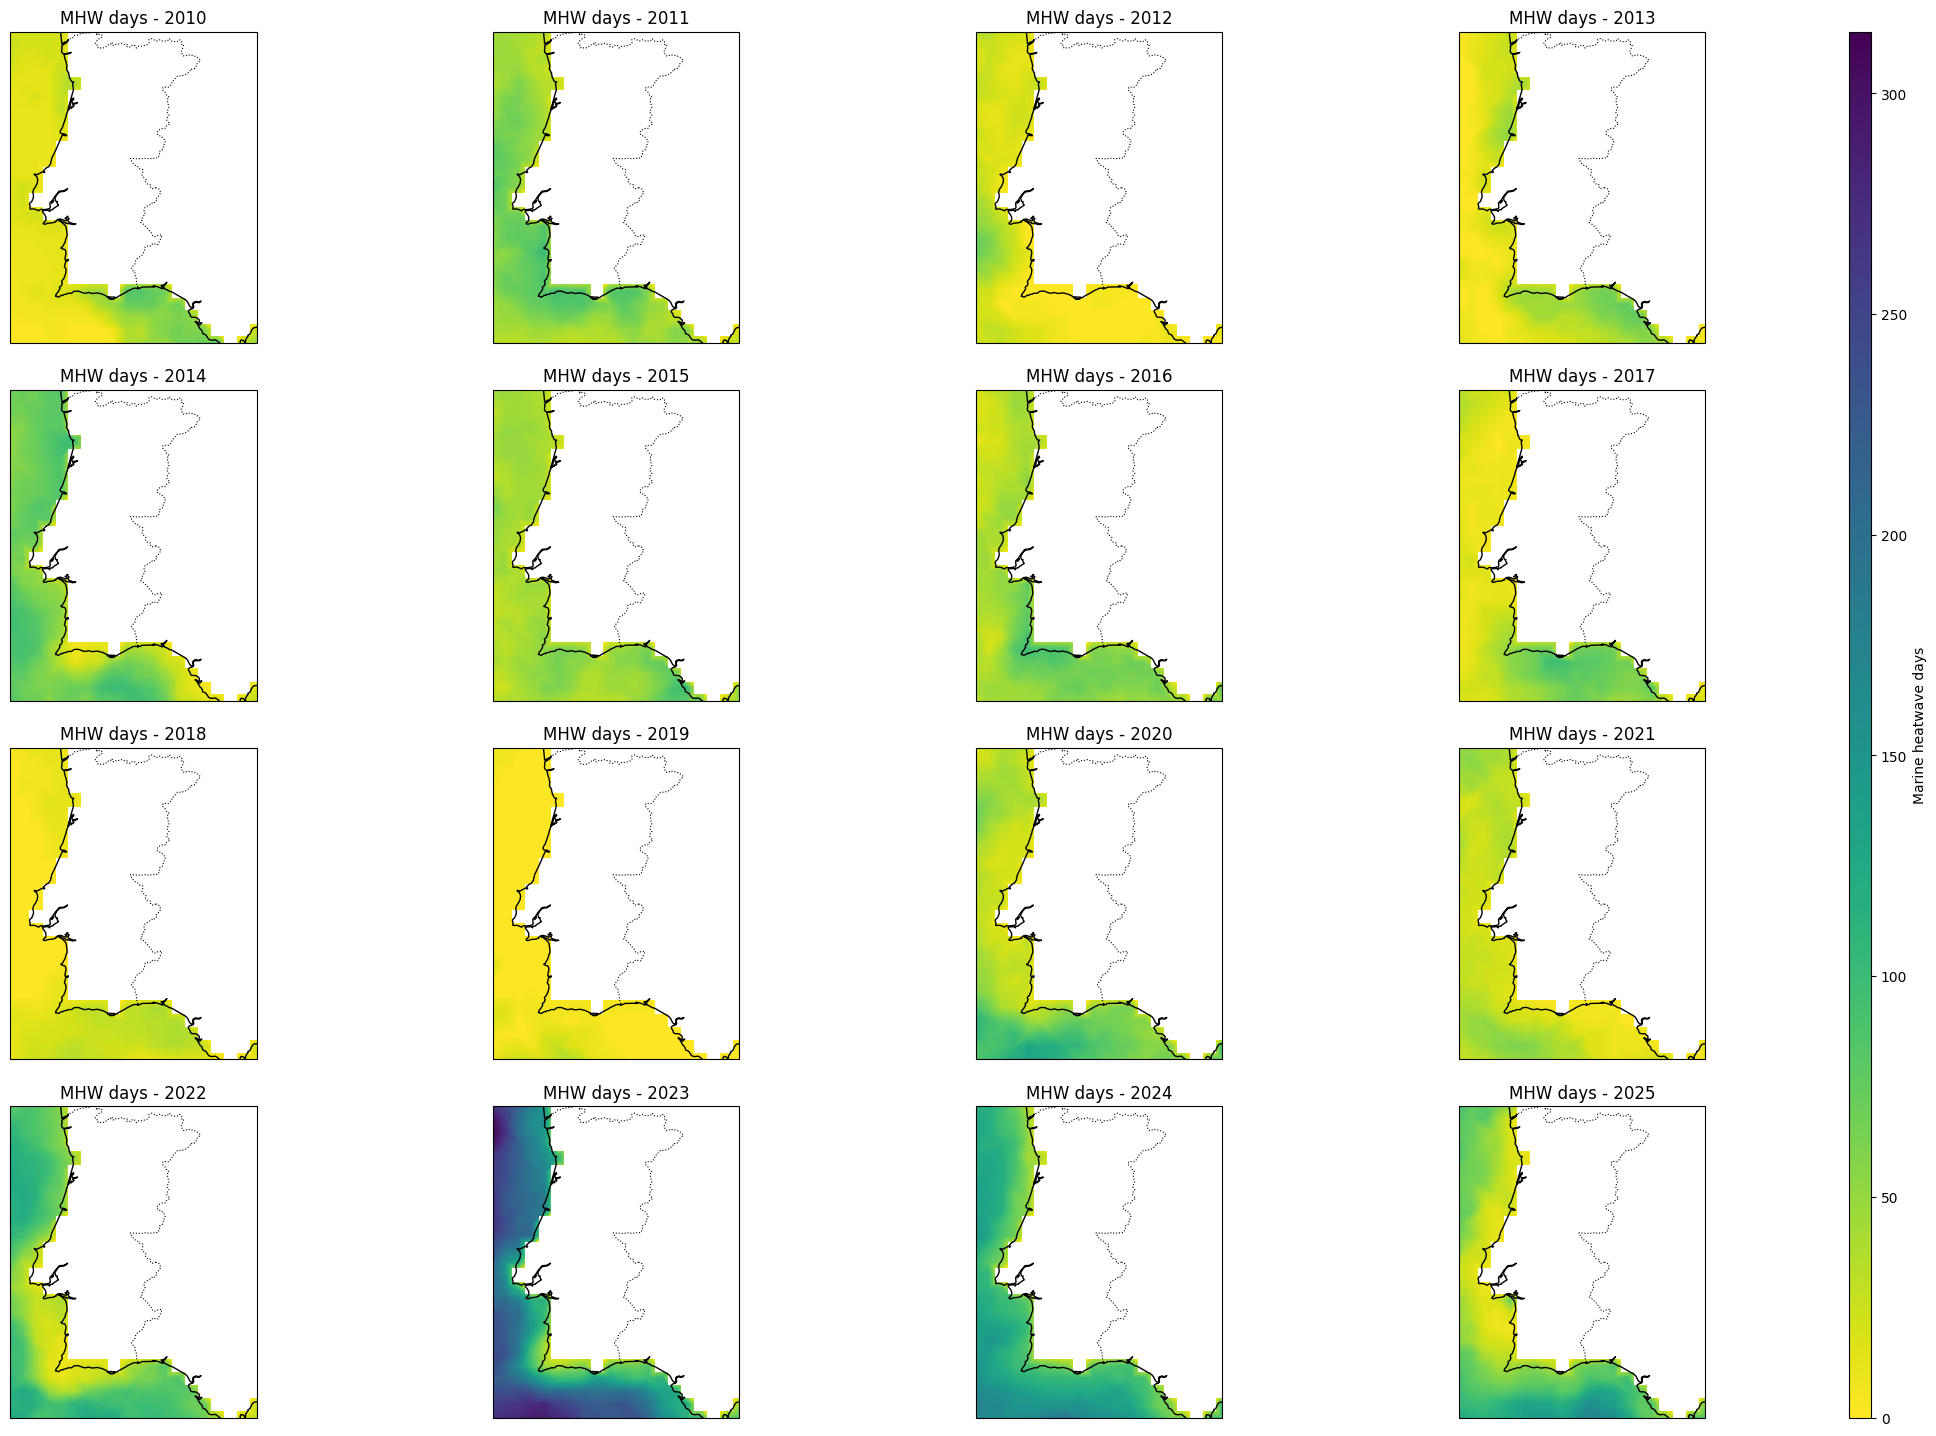

In [ ]:

lon_mask = ds_mask["lon"].values
lat_mask = ds_mask["lat"].values
lon2d_mask, lat2d_mask = np.meshgrid(lon_mask, lat_mask)

# =================================================
# Shared interpolation grid (based on all data)
# =================================================
all_lons = np.concatenate([df["lon"].values for df in yearly_dfs.values()])
all_lats = np.concatenate([df["lat"].values for df in yearly_dfs.values()])

lon_grid = np.linspace(all_lons.min(), all_lons.max(), 300)
lat_grid = np.linspace(all_lats.min(), all_lats.max(), 300)
lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

# =================================================
# Interpolate land–sea mask ONCE
# =================================================
mask_interp = griddata(
    (lon2d_mask.ravel(), lat2d_mask.ravel()),
    ocean_mask.values.ravel().astype(float),
    (lon_grid, lat_grid),
    method="nearest"
)

# =================================================
# Figure layout (SCALABLE)
# =================================================
n_panels = len(yearly_dfs)
ncols = 4
nrows = math.ceil(n_panels / ncols)

fig = plt.figure(figsize=(6 * ncols + 1.2, 4.5 * nrows))

gs = GridSpec(
    nrows,
    ncols + 1,
    width_ratios=[1] * ncols + [0.05],
    wspace=0.15,
    hspace=0.15
)

axes = []
for i in range(n_panels):
    r = i // ncols
    c = i % ncols
    ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
    axes.append(ax)

cax = fig.add_subplot(gs[:, -1])

# =================================================
# Shared color scale
# =================================================
vmin = 0
vmax = max(df["total_duration"].max() for df in yearly_dfs.values())

# =================================================
# Plot each year
# =================================================
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lons = df["lon"].values
    lats = df["lat"].values
    counts = df["total_duration"].values

    # Linear interpolation
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # Nearest fallback (fills coastal gaps)
    grid_counts_nearest = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="nearest"
    )

    grid_counts = np.where(
        np.isnan(grid_counts),
        grid_counts_nearest,
        grid_counts
    )

    # Apply land mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # Map styling
    ax.set_extent(
        [all_lons.min(), all_lons.max(), all_lats.min(), all_lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="viridis_r",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW days - {year}")

# =================================================
# Shared colorbar
# =================================================
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Marine heatwave days")

plt.show()

#### By Max Intensity

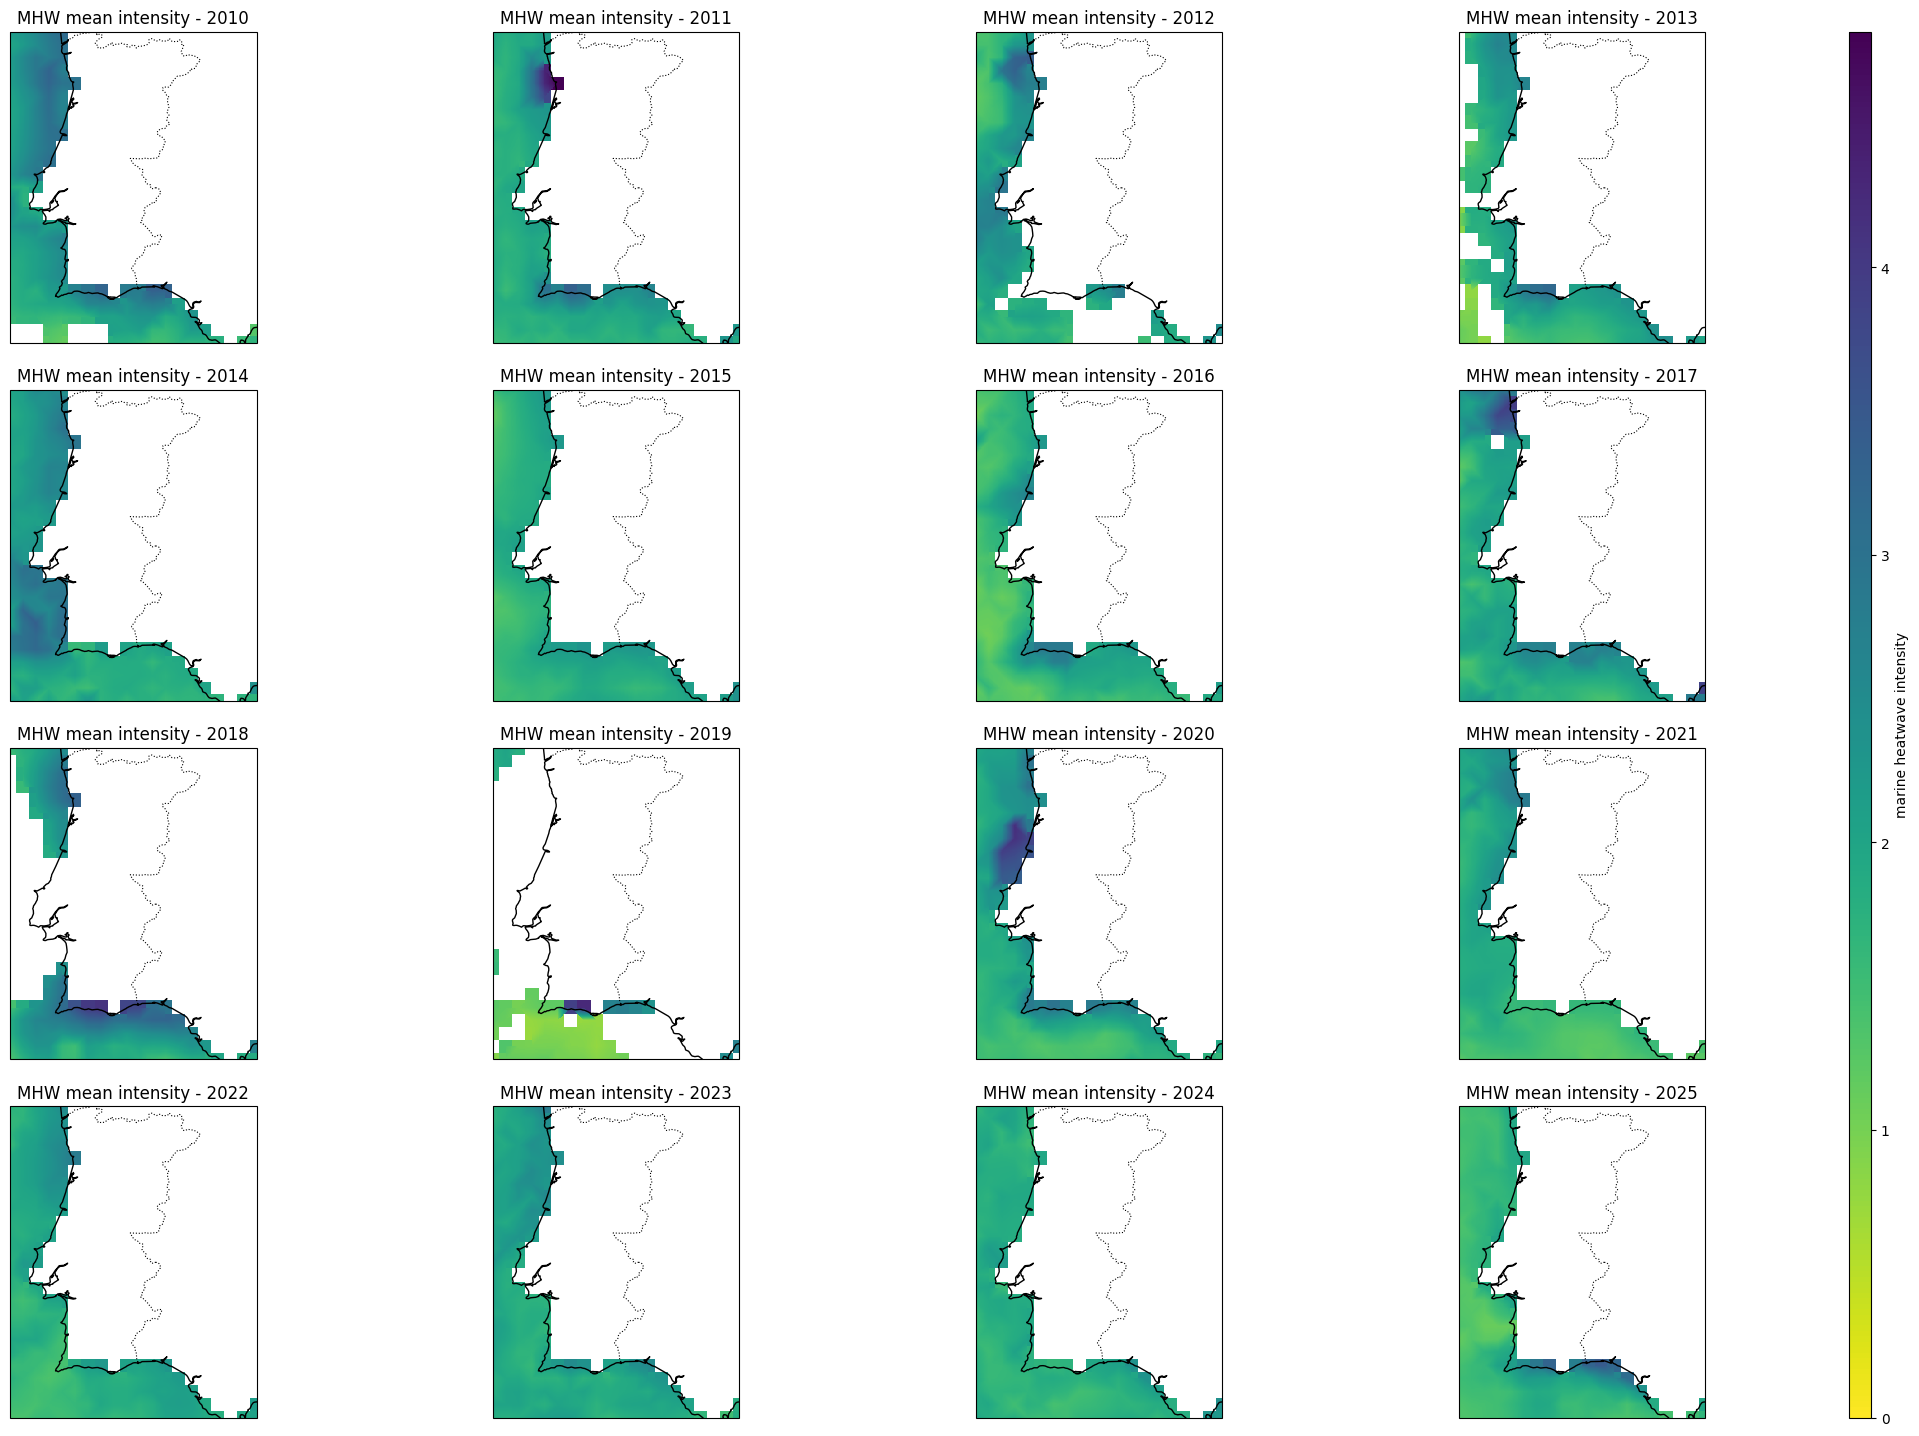

In [ ]:
ocean_mask = ~np.isnan(ds_mask["sst"].isel(time=0))

lon_mask = ds_mask["lon"].values
lat_mask = ds_mask["lat"].values
lon2d_mask, lat2d_mask = np.meshgrid(lon_mask, lat_mask)

# =================================================
# Shared interpolation grid (based on all data)
# =================================================
all_lons = np.concatenate([df["lon"].values for df in yearly_dfs.values()])
all_lats = np.concatenate([df["lat"].values for df in yearly_dfs.values()])

lon_grid = np.linspace(all_lons.min(), all_lons.max(), 300)
lat_grid = np.linspace(all_lats.min(), all_lats.max(), 300)
lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

# =================================================
# Interpolate land–sea mask ONCE
# =================================================
mask_interp = griddata(
    (lon2d_mask.ravel(), lat2d_mask.ravel()),
    ocean_mask.values.ravel().astype(float),
    (lon_grid, lat_grid),
    method="nearest"
)

# =================================================
# Figure layout (SCALABLE)
# =================================================
n_panels = len(yearly_dfs)
ncols = 4
nrows = math.ceil(n_panels / ncols)

fig = plt.figure(figsize=(6 * ncols + 1.2, 4.5 * nrows))

gs = GridSpec(
    nrows,
    ncols + 1,
    width_ratios=[1] * ncols + [0.05],
    wspace=0.15,
    hspace=0.15
)

axes = []
for i in range(n_panels):
    r = i // ncols
    c = i % ncols
    ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
    axes.append(ax)

cax = fig.add_subplot(gs[:, -1])

# =================================================
# Shared color scale
# =================================================
vmin = 0
vmax = max(df["mean_intensity"].max() for df in yearly_dfs.values())

# =================================================
# Plot each year
# =================================================
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lons = df["lon"].values
    lats = df["lat"].values
    counts = df["mean_intensity"].values

    # Linear interpolation
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # Nearest fallback (fills coastal gaps)
    grid_counts_nearest = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="nearest"
    )

    grid_counts = np.where(
        np.isnan(grid_counts),
        grid_counts_nearest,
        grid_counts
    )

    # Apply land mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # Map styling
    ax.set_extent(
        [all_lons.min(), all_lons.max(), all_lats.min(), all_lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="viridis_r",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW mean intensity - {year}")

# =================================================
# Shared colorbar
# =================================================
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("marine heatwave intensity")

plt.show()